# Named Entity Recognition (NER) Pipeline
# Code đầy đủ và data tại: https://github.com/duyhoang17930/Named-Entity-Recognition
## Complete Pipeline: Crawl → Preprocess → label → Encode →  Train → Evaluate → Predict

This notebook contains all steps for building an NER system:
1. **Day1 - Crawl**: Data collection from Google News
2. **Day2 - Preprocess**: Text cleaning and preprocessing
3. **Day3 - Encode**: NER labeling with spaCy
5. **Day4 - Relabeling**: Apply custom entity mappings for improved accuracy
6. **Day5 - Train**: Model training with DistilBERT
7. **Day6 - Results**: Evaluation, visualization, and prediction

In [100]:
{
'PERSON': [
    'Noem', 'Ana Reyes', 'Joe Biden', 'Reyes', 'Kristi Noem', 'Donald Trump', 'Tricia McLaughlin', 'McLaughlin',
    'Clintons', 'Bill', 'Hillary Clinton', 'Jeffrey Epstein', 'Bill Clinton', 'Mike Johnson', 'Johnson', 'Angel Urena',
    'James Comer', 'Comer', 'Elon Musk', 'Ali Javaheri', 'Jensen Huang', 'Sam Altman', 'Altman', 'Don Ho', 'Ho',
    'Kevin Beaumont', 'Alex Karp', 'Karp', 'Peter Thiel', 'Trump', 'JD Vance', 'Modi', 'Narendra Modi', 'Nayara',
    'Alex Pretti', 'Eric C. Tostrud', 'Mary Barra', 'Robert Friedland', 'Stephen Miller', 'Jack', 'Kanishka Singh',
    'Sergei Lavrov', 'Lavrov', 'Delcy Rodriguez', 'Laura Dogu', 'Jorge Rodriguez', 'Gil', 'Dogu', 'Marco Rubio',
    'Nicolas Maduro', 'Rodriguez', 'Peter Attia', 'Attia', 'Bari Weiss', 'Ayatollah Ali Khamenei', 'Khamenei',
    'Mirhossein Mousavi', 'Parisa Hafezi', 'Samia Nakhoul', 'William Maclean', 'Tommy Pigott', 'Pigott',
    'Cesar Andred Aguirre', 'Dania Mariela Escobar', 'Kumar Mangalam Birla', 'Shivangi Acharya', 'Manoj Kumar',
    'Philip Blenkinsop', 'Suzanne P. Clark', 'Clark', 'Piyush Goyal', 'Matt Schlicht', 'Schlicht', 'Ami Luttwak',
    'Luttwak', 'Jamieson O\'Reilly', 'O\'Reilly', 'Ladd Serwat', 'Clay Gaspar', 'Tom Jorden', 'Gaspar', 
    'Gabriele Sorbara', 'Andrew Dittmar', 'Jonas Gahr Stoere', 'Mette-Marit', 'Stoere', 'Marius', 'Haakon',
    'Marius Borg Hoiby', 'Todd Lyons', 'Vladimir Motin', 'Mark Pernia', 'Tom Little', 'Motin', 'Leonard',
    'Pernia', 'Little', 'Mark Angelo Pernia', 'Sturla Henriksboe', 'Henriksboe', 'Ellen Holager Andenaes',
    'Son Heung-min', 'Terence McManus', 'Michael Leuchten', 'Albert Bourla', 'Evan Seigerman', 'Michael Nedelcovych',
    'Karen Andersen', 'Markus Manns', 'Hugh Johnston', 'Bob Iger', 'Josh D\'Amaro', 'Jessica Reif Ehrlich', 'Iger',
    'Larry Ellison', 'Rafael Sotomayor', 'Jens-Frederik Nielsen', 'Nielsen', 'Doug Burgum', 'Abdourahamane Tiani',
    'Mohamed Hamdan Dagalo', 'Dagalo', 'Samir Farag', 'Farag', 'Jeremy Binnie', 'Wim Zwijnenburg', 'Hakan Fidan',
    'Justin Lynch', 'Jalel Harchaoui', 'Volodymyr Zelenskiy', 'Zelenskiy', 'Mark Rutte', 'Oleksiy Kuleba',
    'Ihor Terekhov', 'Denys Shmyhal', 'Natalia Hlobenko', 'Hlobenko', 'Maxim Timchenko', 'Kevin Warsh', 'Warsh',
    'Jim Ferraioli', 'David Morrison', 'Zavier Wong', 'Adam McCarthy', 'Sahak Manuelian', 'Giovanni Staunovo',
    'Tai Wong', 'Steve Witkoff', 'Witkoff', 'Peter Mandelson', 'Mandelson', 'Ella Marriott', 'Sanae Takaichi',
    'Takaichi', 'Takeshi Yamaguchi', 'Savannah Guthrie', 'Nancy Guthrie', 'Chris Nanos', 'Nanos', 'Fidel Castro',
    'Bruno Rodríguez', 'Anne Boleyn', 'Henry VIII', 'Elizabeth I', 'Owen Emmerson', 'Elizabeth', 'Anne',
    'Helene Harrison', 'Nicholas Sanders', 'Harrison', 'Kate McCaffrey', 'Ian Tyers', 'Alistair Darling',
    'Geoffrey Robinson', 'Reinaldo Avila da Silva', 'Nick Butler', 'Chris Wormald', 'Morgan McSweeney',
    'Wes Streeting', 'Robert Maxwell', 'Ghislaine Maxwell', 'Lynn Forester de Rothschild', 'Evelyn', 'Reinaldo',
    'Darren Jones', 'Emily Maitlis', 'Gaby Hinsliff', 'Zoe Williams', 'Polly Toynbee', 'Rafael Behr', 'Keir Starmer',
    'Harvey Weinstein', 'Weinstein', 'Leon Black', 'Black', 'Susan Estrich', 'Maria Farmer', 'Annie', 'Jean-Luc Brunel',
    'Brunel', 'Virginia Giuffre', 'Maxwell', 'Andrew Mountbatten-Windsor', 'Giuffre', 'Sigrid McCawley',
    'Jennifer Freeman', 'Spencer Kuvin', 'David Copperfield', 'Copperfield', 'Lacey Carroll', 'Oprah', 'Villafaña',
    'Susie Roe', 'Roe', 'Becky Roe', 'Susan Roe', 'Marty Baron', 'Nate Silver', 'Silver', 'Sarah Ferguson', 'Sarah',
    'Fergie', 'Mike Sitrick', 'Beatrice', 'Eugenie', 'Glenn Dubin', 'Billie Eilish', 'Kehlani', 'Olivia Dean',
    'Bad Bunny', 'Benito Ocasio', 'Mark Ruffalo', 'Wanda Sykes', 'Sade', 'Amy Winehouse', 'Adele', 'Dua Lipa',
    'Addison Rae', 'Sombr', 'Leon Thomas', 'Ludwig Göransson', 'Henry Walter', 'Greg Kurstin', 'Max Martin',
    'Jack Antonoff', 'Katy Perry', 'Rihanna', 'Miley Cyrus', 'Charli xcx', 'Axel Disasi', 'Nuno Espírito Santo',
    'Jean-Clair Todibo', 'Max Kilman', 'Mamadou Sarr', 'Liam Rosenior', 'Aaron Anselmino', 'David Datro Fofana',
    'Jérémy Jacquet', 'Tyrique George', 'Enzo Maresca', 'Jack Grealish', 'David Moyes', 'Dwight McNeil',
    'Cristian Romero', 'Joel Mvuka', 'Ryan Naderi', 'Evan Mooney', 'Viktor Gyökeres', 'Ben Fisher', 'Joe Aribo',
    'Jamaal Lascelles', 'Divine Mukasa', 'Madiodio Dia', 'John Mousinho', 'Gustavo Caballero', 'Leighton Clarkson',
    'Noah Eile', 'Tomi Horvat', 'Anis Mehmeti', 'Zak Vyner', 'Andy Hunter', 'Angel Gomes', 'Cyle Larin',
    'Junior Hoilett', 'Rob Edwards', 'Wayne Rooney', 'Wes Harding', 'Alex Reid', 'Karim Benzema', 'Kalvin Phillips',
    'Nilson Angulo', 'Ryan Hardie', 'Dennis Geiger', 'Andrew Moran', 'Saba Goglichidze', 'Javi Gracia', 'Joe Rothwell',
    'James Wilson', 'Ange Postecoglou', 'Simon Adingra', 'Luca Netz', 'Julian Mentz', 'Junior Adamu', 'Johnny Kenny',
    'Marvelous Nakamba', 'Gabriele Biancheri', 'Arne Engels', 'Rodri', 'Dominic Solanke', 'Arsène Wenger',
    'Yannick Woudstra', 'Maro Itoje', 'Jamie George', 'Henry Arundell', 'Tommy Freeman', 'Florence', 'Genge',
    'Ellis Genge', 'George Ford', 'Tom Roebuck', 'Samuel López', 'Jannik Sinner', 'Daniil Medvedev', 'Rafael Nadal',
    'Roger Federer', 'Elena Rybakina', 'Júnior Pena', 'Eustáquio da Silva Pena Júnior', 'Lula da Silva', 'Jair Bolsonaro',
    'Andrew Lattarulo', 'Wael Tarabishi', 'Maher', 'Wael', 'Shahd Arnaout', 'Ali Elhorr', 'Joanna Cuevas Ingram',
    'Baher Azmy', 'Hakeem Jeffries', 'Ro Khanna', 'Thomas Massie', 'Pam Bondi', 'Jamie Raskin', 'Kemi Badenoch',
    'Faisal Islam', 'Nick Macpherson', 'Jeff Bezos', 'Will Lewis', 'Edward Snowden', 'Jason Rezaian', 'Mehdi Mahmoudian',
    'Ali Khamenei', 'Vida Rabbani', 'Abdullah Momeni', 'Jafar Panahi', 'Matthew Michelsen', 'Chris Vanek', 'Eddie Vasquez',
    'Mahmud Azem', 'Amichai Eliyahu', 'Wala ’ a Ghazal', 'Mahmud Ghazal', 'Thorbjørn Jagland', 'Tymur Tkachenko',
    'Masoud Pezeshkian', 'Abbas Araghchi', 'Sarah Breeden', 'Rebecca Jackson', 'Raphael Bostic', 'Fritz Emmanuel Lesly Miot',
    'Rudolph Civil', 'Marlene Gail Noble', 'Marica Merline Laguerre', 'Vilbrun Dorsainvil', 'Margaret Baum',
    'Ender Perea', 'Jose Luis Galindo', 'Lin Jian', 'Teeranan Nandhakwang', 'Touch Sokhak', 'Shahid Rind', 'Sarfraz Bugti',
    'Bakht Muhammad Kakar', 'Joe Abate', 'David Beckworth', 'Scott Anderson', 'Marc Jones', 'Wayne Cole', 'Sonali Paul',
    'Moustafa Abdel Hadi', 'Giovanni Staunovo', 'Tony Sycamore', 'Vivek Dhar', 'Nawar Rahawi', 'Noah Bonsey', 'Tim Ghriskey',
    'Michael Hsueh', 'John Meyer'
],
'ORG': [
    'Reuters', 'U . S . Department of Homeland Security', 'Department of Homeland Security', 'Haiti\'s',
    'Homeland Security', 'TPS', 'United States', 'Congress', 'xAI', 'SpaceX', 'Alphabet', 'Google', 'Meta',
    'Amazon', 'Anthropic', 'OpenAI', 'LSEG', 'Wall Street Journal', 'Neuralink', 'Boring Company', 'Starlink',
    'PitchBook', 'NASA', 'Department of Defense', 'New York Times', 'Verge', 'Nvidia', 'AMD', 'Cerebras', 'Groq',
    'ChatGPT', 'Codex', 'TPUs', 'MarketWatch', 'Barron s', 'Trent University', 'Yahoo Finance', 'NHTSA',
    'Waymo', 'Dragoneer Investment Group', 'DST Global', 'Sequoia Capital', 'Mubadala Capital', 'Andreessen Horowitz',
    'T . Rowe Price', 'Tracxn', 'Tesla', 'Zoox', 'UNICEF', 'House Oversight Committee', 'US DOJ', 'House',
    'House of Representatives', 'U . S . Justice Department', 'Black Lives Matter', 'NATO', 'Supreme Court',
    'Palantir Technologies', 'Palantir', 'ICE', 'CapGemini', 'CIA', 'Senate', 'Air Force One', 'Truth Social',
    'Indian Oil Corp', 'Bharat Petroleum Corp', 'Nayara Energy', 'Reliance Industries', 'PDVSA', 'European Union',
    'Bitfinex', 'Charles Schwab', 'Microsoft', 'Azure', 'American Banker', 'Federal Reserve', 'Notepad++',
    'Cybersecurity and Infrastructure Security Agency', 'Rapid7', 'Lotus Blossom', 'BCA', 'Hennepin County Attorney ’ s Office',
    'DHS', 'Dominion Voting Systems', 'Fox News', 'Foreign Ministry', 'National Assembly', 'National Immigration Law Center',
    'State Department', 'Aditya Birla Group', 'Reserve Bank of India', 'Chamber of Commerce', 'U.S.-India Business Council',
    'G7', 'HMRC', 'Institute for Supply Management', 'FHN Financial', 'BMO Capital Markets', 'EXIM Bank',
    'MP Materials', 'USA Rare Earth Inc', 'General Motors', 'Hartree Partners', 'Traxys North America',
    'Mercuria Energy Group', 'Costco', 'University of Maine', 'Columbia Journalism School', 'Islamic State',
    'SITE Intelligence Group', 'ACLED', 'ISWAP', 'ASKY Airlines', 'Air Cote d\'Ivoire', 'Devon Energy',
    'Coterra Energy', 'Diamondback', 'Endeavor Energy Resources', 'Siebert Williams Shank & Co.', 'Kimmeridge',
    'Enverus Intelligence Research', 'Security Council', 'Norstat', 'NRK', 'J.P. Morgan', 'JP Morgan', 'CME Group',
    'Commonwealth Bank of Australia', 'CBA', 'TrendForce', 'Equinor', 'Vista Energy', 'Verdi', 'Deutsche Bahn',
    'S-Bahn', 'City Index', 'FOREX.com', 'Met', 'HSTS', 'Boervolk of the Orange Free State', 'Orania', 'U.N.',
    'Kalameh', 'Moltbook', 'Wiz', 'OpenClaw', 'Clawdbot', 'Moltbot', 'Vall d\'Hebron', 'Health Ministry',
    'Nezopont Institute', 'Publicus Institute', 'Mi Hazank', 'Fidesz', 'Tisza', 'Ant International', 'Alipay+',
    'NPCI', 'Exxon Mobil', 'ConocoPhillips', 'ISIS', 'Board of Peace', 'SPR', 'Vulcan Elements', 'Infosys',
    'Wipro', 'HDFC Bank', 'iShares MSCI India', 'World Trade Organization', 'Emkay Global', 'Uefa', 'Saja Boys',
    'Huntr/x', 'FKA twigs', 'Recording Academy', 'Netflix', 'RB Leipzig', 'Burnley', 'West Ham', 'Chelsea',
    'Aston Villa', 'Southampton', 'Bournemouth', 'Tottenham', 'Rennes', 'Liverpool', 'Bayern Munich', 'St Mirren',
    'Santos', 'Bristol City', 'Crystal Palace', 'Sturm Graz', 'Ipswich', 'Wrexham', 'Marseille', 'Hibernian',
    'Swindon Town', 'Millwall', 'Plymouth', 'Udinese', 'Huddersfield', 'Aberdeen', 'Bolton', 'Luton Town',
    'Rotherham', 'Al-Hilal', 'Al-Ahli', 'Al-Ittihad', 'PIF', 'Al-Riyadh', 'Quilter Cheviot', 'LDP',
    'Liberal Democratic Party', 'AJ Bell', 'BMO', 'Citizens for Responsibility and Ethics in Washington',
    'Aryam Investment', 'World Liberty Financial', 'Binance', 'MGX', 'Marsh Law', 'Boies Schiller Flexner',
    'Goldlaw', 'Guardian', 'MGM Grand Hollywood Theater', 'Harbottle & Lewis', 'Carter Ruck', 'Wayback Machine',
    'Emek Shaveh', 'Otzma Yehudit', 'City of David Foundation', 'Elad', 'Unesco', 'Al-Aqsa Martyrs Hospital',
    'FPA', 'SNP', 'Reform UK', 'Foreign Press Association', 'BBC', 'Global Counsel', 'Privy Council', 'NLGJA',
    'State Information Service', 'DTEK', 'Vantor', 'CBOE', 'NXP Semiconductors', 'Boeing', 'Gothams LLC',
    'Gothams', 'Planned Parenthood Great Rivers', 'Morena', 'MSCI', 'CBA \' s', 'Vanguard', 'Cerulli Associates',
    'Morningstar', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce', 'TrendForce'
],
'GPE': [
    'U . S .', 'Washington', 'D . C .', 'Haiti', 'United States', 'New York', 'Florida', 'China', 'India', 'Kyiv',
    'Russia', 'Ukraine', 'San Francisco', 'Germany', 'USA', 'Venezuela', 'Minnesota', 'Frankfurt', 'Canada',
    'Pakistan', 'Afghanistan', 'Italy', 'France', 'Belgium', 'Portugal', 'Netherlands', 'Norway', 'Sweden',
    'Denmark', 'Spain', 'Honduras', 'Nicaragua', 'Nepal', 'Cameroon', 'Somalia', 'Eritrea', 'Brazil', 'Uruguay',
    'Bosnia', 'Albania', 'Bangladesh', 'Taiwan', 'Israel', 'Japan', 'Mexico', 'South Korea', 'Argentina',
    'Turkey', 'Egypt', 'Sudan', 'Libya', 'Qatar', 'Saudi Arabia', 'UAE', 'Ivory Coast', 'Benin', 'Mali',
    'Burkina Faso', 'Jordan', 'Guatemala', 'South Sudan', 'Iraq', 'Lebanon', 'Gaza', 'UK', 'Singapore', 'Britain',
    'Surin', 'Taizhou', 'Luebeck', 'Nuremberg', 'Stuttgart', 'Karlsruhe', 'Freiburg', 'Hamburg', 'Bremen', 'Munich',
    'Istanbul', 'Dnipropetrovsk', 'Zaporizhzhia', 'Kharkiv', 'Donetsk', 'Izium', 'Balakliia', 'Sumy', 'Abu Dhabi',
    'Tirana', 'Lhasa', 'Dharamshala', 'Nuuk', 'Lagos', 'Murcia', 'El Palmar', 'Moscow', 'Oslo', 'Saint Paul',
    'Texas', 'New Mexico', 'Oklahoma', 'Maine', 'Boston', 'Tucson', 'Arizona', 'Michigan', 'Montana', 'Nevada',
    'Ohio', 'Darfur', 'al-Fashir', 'Nyala', 'Hainan', 'Corfu', 'Gorton', 'Denton', 'Hartlepool', 'Foy', 'Porchester',
    'Barcelona', 'Houston', 'Rhode Island', 'Providence', 'Oklahoma City', 'Murcia', 'El Palmar', 'St Petersburg'
],
'LOC': [
    'Strait of Hormuz', 'Arabian Sea', 'Caribbean', 'Arctic', 'Permian Basin', 'Delaware Basin', 'Anadarko Basin',
    'Silicon Valley', 'Gulf', 'Middle East', 'Africa', 'Southeast Asia', 'Central America', 'South America',
    'West Bank', 'East Jerusalem', 'Jerusalem', 'Vaca Muerta', 'Sahel', 'Lake Chad', 'Nile River', 'Gaza Strip',
    'Mediterranean', 'Capitol', 'Potomac River', 'Selhurst Park', 'London Stadium', 'Etihad Stadium',
    'Allianz Stadium', 'Stamford Bridge', 'Old City', 'Central Park', 'Musha Cay', 'Palm Beach', 'Hever',
    'East Oweinat', 'Ain al-Arab', 'Kobani', 'Nyala', 'al-Fashir', 'East Asia', 'Lake Chad basin'
],
'NORP': [
    'nonwhite', 'Haitians', 'Haitian', 'Democratic', 'Republican', 'Democrats', 'Republicans', 'Russian', 'Ukrainian',
    'Chinese', 'British', 'French', 'Indian', 'European', 'Western', 'Arab', 'Afghan', 'Islamic', 'jihadist',
    'Kurdish', 'Tibetan', 'Buddhist', 'Alawites', 'Druze', 'Inuit', 'Afrikaners', 'Dutch', 'Zulu', 'Brazilian',
    'Venezuelan', 'Pakistani', 'Salvadoran', 'Emirati', 'Slovenian', 'Paraguayan', 'Ecuador', 'Finnish', 'Swedish',
    'Danish', 'Norwegian', 'Australian', 'American', 'Canadian', 'Asian', 'Latin American', 'Balkan', 'South Asian',
    'Caribbean', 'African', 'Black', 'white', 'KPop', 'English', 'Catholic', 'Anglican', 'Boervolk', 'Scandis',
    'Maya', 'Quetta', 'Baloch', 'Taliban', 'Al-Nassr', 'Al-Ahli', 'Al-Ittihad', 'Al-Hilal', 'RB Leipzig',
    'Eintracht', 'Sturm Graz', 'LDP', 'Ishin', 'Morena', 'Portuguese', 'Hebrew', 'Asayish'
],
'PRODUCT': [
    'Grok', 'ChatGPT', 'Azure', 'Notepad++', 'Model Y', 'Model 3', 'Model S', 'Model X', 'DRAM', 'GE9X', '777X',
    'Akinci', 'Bayraktar', 'UAV', 'Airbus A319', 'LPG', 'Ether', 'Bitcoin', 'GNX', 'Wegovy', 'Zepbound', 'Ozempic',
    'GPUs', 'TPUs', 'SRAM', 'Solong', 'Stena Immaculate', 'Chrysopigi Lady', 'Yuanbao', 'Qwen', 'OpenClaw', 'Clawd',
    'Clawdbot', 'Moltbot', 'iOS', 'Android', 'Windows'
],
'WORK_OF_ART': [
    'Constitution\'s', 'Fifth Amendment', 'Pulitzer Prize', 'It Was Just an Accident', 'Palme d ’ Or', 'Oscars',
    'Academy Awards', 'The Art of Loving', 'Meditations', 'Outlive', 'Oro Rojo', '60 Minutes', 'Hamilton',
    'Moulin Rouge', 'Mrs. Doubtfire', 'The Outsiders', 'Zootopia 2', 'Avatar : Fire and Ash', 'Lincoln',
    'Capturing a Queen', 'Rose', 'The Dan Bongino Show', 'Vanity Fair', 'Wall Street Journal', 'Evening Standard',
    '60 Minutes', 'Outlive : The Science and Art of Longevity', 'The Many Faces of Anne Boleyn', 'Wicked',
    'Without Further Ado , Vol One', 'Songs of a Lost World', 'Wish', 'Bloodflowers'
],
'DATE': [
    'Wednesday', 'Feb 2', 'Monday', '2016', 'July 2024', 'February 3 , 2026', 'February 2025', 'August',
    'November', 'October', 'July', '2010', '2024', 'last week', 'early 2000s', '2021', '2019', '2000',
    'September', 'January 30', 'January', '2023', 'Dec 2', 'June 2025', 'September 2 , 2025', 'December 2 , 2025',
    'January 21', 'April 9 , 2025', 'August 27 , 2025', 'January 27 , 2026', 'last year', 'Feb 3', 'Tuesday',
    'Sunday', 'Thursday', 'Saturday', 'midterm', '2022', '17th century', '1840', '20th century', '1910', '1994',
    '1837', '2027', 'January 23', 'December 27', 'February 13 , 2025', 'April', 'mid-2025', 'April 10', 'July 31',
    'August 7', 'June', 'March', 'April 12', '1983', '1979', '2008', '2007', '2011', '2014', '2013', '2012',
    '2015', '2018', '2020', '2004', '2005', '1993', '1992', '1980s', '1970s', '1990s', '1391', '1536',
    'February 15', 'Lunar New Year', 'Valentine ’ s Day', 'Christmas', 'January 24', 'June 3', 'January 21-24',
    'January 26-27', 'February 6', 'August 27', 'May 9 2010', '26 January 2021', 'July 4', '250th anniversary',
    'September 29', 'December 28', 'January 9', 'September 2010', '11 September 2013', 'April 2003', 'May 2024',
    'October 2024', 'February 2024', 'March 2025', 'September 2025', 'August 2025', 'January 15', 'October 2010'
],
'MONEY': [
    '250 billion', '1 trillion', '203 billion', '800 billion', '230 billion', '1.5 trillion', '100 billion',
    '20 billion', '14 billion', '570 million', '1 . 41 billion', '30 million', '12 billion', '10 billion',
    '1.1 billion', '21.4 billion', '700 million', '5 billion', '250 million', '350 million', '431 million',
    '3 billion yuan', '1 billion yuan', '500 million yuan', '20,000 pounds', '2 billion', '45 billion',
    '50 billion', '300 billion', '40 million', '£55m', '£5m', '£22m', '£20m', '£15m', '£2.5m', '£1m', '£3m',
    '£9m', '£34.6m', '£13m', '£35m', '£30m', '£26m', '£21.5m', '£100m', '£12m', '$ 500bn', '$ 5,594.82',
    '$ 4,700', '$ 900', '$ 6,200/oz', '$ 6,300/oz', '$ 6,000', '$ 5,000', '$ 1,000', '$ 149', '$ 299',
    '$ 121.64', '$ 76.81', '$ 25,000', '$ 75,000', '£10,000', '£3,250', '£20bn', '€500bn', '$ 36 million',
    '$ 187m', '$ 31m', '$ 70bn', '$ 40m', '$ 578m', '$ 144', '$ 3.05 billion', '$ 3.25 billion', '$ 3.10 billion',
    '$ 3.34 billion', '$ 3.31 billion', '$ 3.35', '$ 3.27', '£16bn', '£3.74m', '£870k', '$ 787 million',
    '$ 10bn', '$ 1.67bn', '140,000 won', '$ 97', '$ 12bn'
],
'QUANTITY': [
    '7 . 0 magnitude', '18 months', '6 million', '3.3 million', '60 km', '37 miles', '18 miles per hour',
    '29 kph', '400 kg', '3.5 kg', '7.72 pounds', '1.2 million barrels', '800,000 bpd', '20 Celsius',
    '4 Fahrenheit', '250-foot', '76-meter', '220,000 barrels', '50 million barrels', '1.2m barrels',
    '10 %', '120 billion', '130 billion', '158 billion', '105 billion', '134 billion', '126 billion',
    '182 hectares', '450 acres', '40 million barrels', '847,000 bpd', '867,000 bpd', '284,000 bpd',
    '220,000 bpd', '99,000 bpd', '156,000 bpd', '392,000 bpd', '400,000 barrel per day', '1.6 million barrels',
    '1 million bpd', '800,000 bpd', '394,000 barrels per day', '8.26 million barrels', '41.72 million barrels',
    '46.25 million barrels', '10 million barrels'
],
'CARDINAL': [
    '350 , 000', '1 . 4 million', '0 . 1433', '104 , 782 . 88', '126 , 000', '78 , 396', '1 , 142', 
    '270 , 000', '20.1 billion', '19.4 billion', '527', '871', '16,000', '3,000', '1,700', '3 million', 
    '6 million', '3.5m', '6m', '10', '12', '15', '16', '18', '20', '25', '26', '30', '35', '38', '39', 
    '40', '41', '43', '46', '50', '53', '60', '70', '75', '80', '84', '88', '90', '92', '100', '109', 
    '115', '129', '133', '150', '160', '167', '200', '217', '218-213', '233', '465', '700', '961',
    '125 to 150', '30', '11', '800', '3.14 billion', '1.63', '1.57', '110 million', '450 million',
    '100 million', '2.77', '3.17', '2.97', '2.90', '16', '2.8 %', '166.67', '0.34 %', '49,240.99',
    '58.63', '0.84 %', '6,917.81', '336.92', '1.43 %', '23,255.19', '0.16', '0.02 %', '1,043.93',
    '1.03 %', '2.2 %', '3.3 %', '1.72 %', '1.07', '63.21', '67.33', '1.55 %', '1.03', '6.14 %',
    '4,951.72', '7.58 %', '85.42', '1.08 %', '0.7022', '3.85 %', '4.268 %', '4.277 %', '1.1', '4.8983',
    '0.2', '3.572 %', '3.57 %', '426', '6,300', '10,000', '1,030', '29', '38', '961', '500,000',
    '187m', '31m', '17', '15.7 million', '720 million', '68,000', '10.1 %', '0.7 %'
],
'ORDINAL': ['Fifth', 'first', 'second', 'third', 'fourth', '14th', '90th', '250th', '11th'],
'TIME': [
    'Monday night', 'Saturday night', 'Sunday afternoon', '11pm', '8pm', '9pm', '19:00', '17:00', '21:00',
    '1600ish', 'midnight', 'early morning', 'late afternoon', '0450 GMT', 'nightfall', 'afternoon'
],
'LANGUAGE': ['Kanuri', 'Portuguese', 'Hebrew', 'French', 'English', 'Spanish'],
'FAC': [
    'White House', 'Oval Office', 'East Wing', 'Miraflores presidential palace', 'Buckingham Palace',
    'Royal Lodge', 'Tower of London', 'Old Bailey', 'Stamford Bridge', 'London Stadium', 'Etihad Stadium',
    'Allianz Stadium', 'Selhurst Park', 'Musha Cay', 'East Oweinat', 'Charles de Gaulle airport',
    'Niamey airport', 'Jose port', 'National Archives', 'MGM Grand Hollywood Theater', 'Al-Aqsa Martyrs Hospital'
]
}

{'PERSON': ['Noem',
  'Ana Reyes',
  'Joe Biden',
  'Reyes',
  'Kristi Noem',
  'Donald Trump',
  'Tricia McLaughlin',
  'McLaughlin',
  'Clintons',
  'Bill',
  'Hillary Clinton',
  'Jeffrey Epstein',
  'Bill Clinton',
  'Mike Johnson',
  'Johnson',
  'Angel Urena',
  'James Comer',
  'Comer',
  'Elon Musk',
  'Ali Javaheri',
  'Jensen Huang',
  'Sam Altman',
  'Altman',
  'Don Ho',
  'Ho',
  'Kevin Beaumont',
  'Alex Karp',
  'Karp',
  'Peter Thiel',
  'Trump',
  'JD Vance',
  'Modi',
  'Narendra Modi',
  'Nayara',
  'Alex Pretti',
  'Eric C. Tostrud',
  'Mary Barra',
  'Robert Friedland',
  'Stephen Miller',
  'Jack',
  'Kanishka Singh',
  'Sergei Lavrov',
  'Lavrov',
  'Delcy Rodriguez',
  'Laura Dogu',
  'Jorge Rodriguez',
  'Gil',
  'Dogu',
  'Marco Rubio',
  'Nicolas Maduro',
  'Rodriguez',
  'Peter Attia',
  'Attia',
  'Bari Weiss',
  'Ayatollah Ali Khamenei',
  'Khamenei',
  'Mirhossein Mousavi',
  'Parisa Hafezi',
  'Samia Nakhoul',
  'William Maclean',
  'Tommy Pigott',
  'Pi

In [16]:
# Step 4: Relabeling with Custom Mappings (Day4)
# Apply rule-based relabeling to improve entity accuracy

import json
import csv
import ast
import re

def normalize_token(token):
    """Normalize token by removing unicode chars and punctuation"""
    token = re.sub(r'[\u200b\u2060\u200c\u200d\u00a0]', '', token)
    token = token.strip('.,;:!?()[]{}\'"-')
    return token.lower().strip()

def load_entity_mappings(json_path):
    """Load entity mappings from data.json"""
    with open(json_path, 'r', encoding='utf-8') as f:
        content = f.read()
        data = ast.literal_eval(content)

    entity_map = {}
    multi_word_map = {}

    for entity_type, entities in data.items():
        for entity in entities:
            entity_normalized = entity.lower().strip()
            entity_map[entity_normalized] = entity_type

            words = entity_normalized.split()
            if len(words) >= 2:
                if words[0] not in multi_word_map:
                    multi_word_map[words[0]] = []
                multi_word_map[words[0]].append({
                    'phrase': entity_normalized,
                    'type': entity_type,
                    'words': words
                })

    return entity_map, multi_word_map

def relabel_data(csv_path, entity_map, multi_word_map, output_path):
    """Relabel tokens using custom entity mappings"""
    results = []

    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:
            tokens = ast.literal_eval(row['tokens'])
            labels = ast.literal_eval(row['labels'])

            new_labels = []
            i = 0
            while i < len(tokens):
                token = tokens[i]
                token_lower = normalize_token(token)
                original_label = labels[i]

                # Check for multi-word phrase matches first
                if token_lower in multi_word_map:
                    matched = False
                    for phrase_info in multi_word_map[token_lower]:
                        phrase_words = phrase_info['words']
                        phrase_len = len(phrase_words)

                        if i + phrase_len <= len(tokens):
                            remaining_tokens = [normalize_token(t) for t in tokens[i:i+phrase_len]]
                            if remaining_tokens == phrase_words:
                                for j in range(phrase_len):
                                    if j == 0:
                                        new_labels.append(f'B-{phrase_info["type"]}')
                                    else:
                                        new_labels.append(f'I-{phrase_info["type"]}')
                                i += phrase_len
                                matched = True
                                break
                    if matched:
                        continue

                # Check single token match
                if token_lower in entity_map:
                    entity_type = entity_map[token_lower]
                    if i > 0 and new_labels[i-1].endswith(f'-{entity_type}'):
                        new_labels.append(f'I-{entity_type}')
                    else:
                        new_labels.append(f'B-{entity_type}')
                else:
                    if i > 0 and new_labels[i-1].startswith('B-') and original_label.startswith('I-'):
                        prev_type = new_labels[i-1][2:]
                        new_labels.append(f'I-{prev_type}')
                    else:
                        new_labels.append(original_label)

                i += 1

            results.append({
                'tokens': tokens,
                'labels': new_labels
            })

    # Write results
    with open(output_path, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['tokens', 'labels'])
        writer.writeheader()
        for result in results:
            writer.writerow({'tokens': str(result['tokens']), 'labels': str(result['labels'])})

    return len(results)

# Run relabeling
print("Loading entity mappings from Day4.5_Relabeling/data.json...")
entity_map, multi_word_map = load_entity_mappings('Day4.5_Relabeling/data.json')
print(f"Loaded {len(entity_map)} single token mappings")
print(f"Loaded {len(multi_word_map)} multi-word phrase starting words")

print("\nRelabeling data (Day4.5)...")
count = relabel_data('manual_labeled.csv', entity_map, multi_word_map, 'relabeled_output.csv')
print(f"Relabeled {count} rows")
print(f"Output saved to: relabeled_output.csv")

Loading entity mappings from Day4.5_Relabeling/data.json...
Loaded 1342 single token mappings
Loaded 575 multi-word phrase starting words

Relabeling data (Day4.5)...
Relabeled 3113 rows
Output saved to: relabeled_output.csv


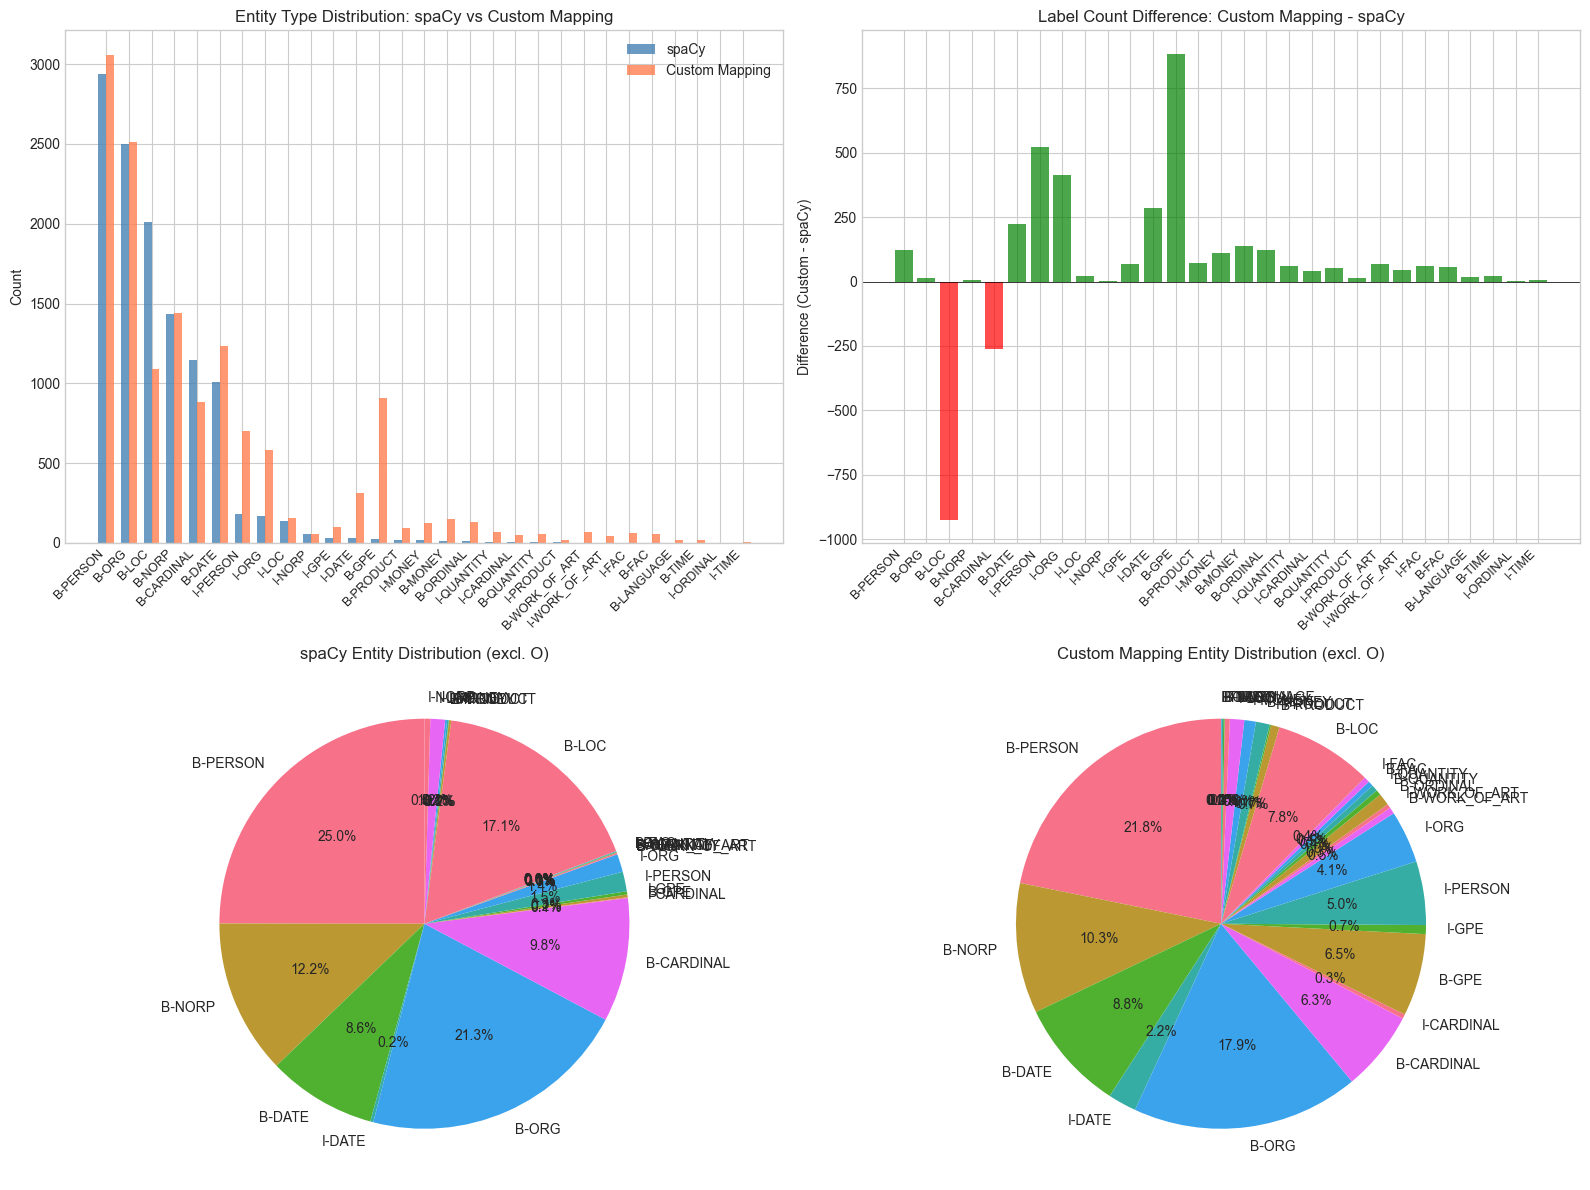


=== Label Comparison Summary ===
spaCy total labels: 97724
Custom Mapping total labels: 97724

spaCy unique entities: 25
Custom Mapping unique entities: 29

Saved: charts/spacy_vs_custom_mapping_comparison.png


In [38]:
# Visualization: spaCy vs Custom Mapping Labels Comparison
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load both datasets
df_spacy = pd.read_csv('Day4.5_Relabeling/manual_labeled.csv')  # spaCy labels
df_custom = pd.read_csv('Day4.5_Relabeling/relabeled_output.csv')  # Custom mapping labels

# Parse labels
def get_label_counts(df):
    all_labels = []
    for labels in df['labels']:
        parsed = ast.literal_eval(labels)
        all_labels.extend(parsed)
    return Counter(all_labels)

spacy_counts = get_label_counts(df_spacy)
custom_counts = get_label_counts(df_custom)

# Get unique entity types (excluding 'O')
entity_types = sorted(set(spacy_counts.keys()) | set(custom_counts.keys()))
entity_types = [e for e in entity_types if e != 'O']

# Create comparison dataframe
comp_df = pd.DataFrame({
    'Entity': entity_types,
    ' spaCy': [spacy_counts.get(e, 0) for e in entity_types],
    'Custom Mapping': [custom_counts.get(e, 0) for e in entity_types]
})
comp_df = comp_df.sort_values(' spaCy', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Side-by-side bar chart
x = range(len(comp_df))
width = 0.35
axes[0, 0].bar([i - width/2 for i in x], comp_df[' spaCy'], width, label='spaCy', color='steelblue', alpha=0.8)
axes[0, 0].bar([i + width/2 for i in x], comp_df['Custom Mapping'], width, label='Custom Mapping', color='coral', alpha=0.8)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(comp_df['Entity'], rotation=45, ha='right', fontsize=9)
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Entity Type Distribution: spaCy vs Custom Mapping')
axes[0, 0].legend()

# 2. Difference (custom - spacy)
comp_df['Difference'] = comp_df['Custom Mapping'] - comp_df[' spaCy']
colors = ['green' if d > 0 else 'red' for d in comp_df['Difference']]
axes[0, 1].bar(comp_df['Entity'], comp_df['Difference'], color=colors, alpha=0.7)
axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xticklabels(comp_df['Entity'], rotation=45, ha='right', fontsize=9)
axes[0, 1].set_ylabel('Difference (Custom - spaCy)')
axes[0, 1].set_title('Label Count Difference: Custom Mapping - spaCy')

# 3. Pie chart for spaCy
spacy_entity = {k: v for k, v in spacy_counts.items() if k != 'O'}
axes[1, 0].pie(spacy_entity.values(), labels=spacy_entity.keys(), autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('spaCy Entity Distribution (excl. O)')

# 4. Pie chart for Custom Mapping
custom_entity = {k: v for k, v in custom_counts.items() if k != 'O'}
axes[1, 1].pie(custom_entity.values(), labels=custom_entity.keys(), autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Custom Mapping Entity Distribution (excl. O)')

plt.tight_layout()
plt.savefig('charts/spacy_vs_custom_mapping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== Label Comparison Summary ===")
print(f"spaCy total labels: {sum(spacy_counts.values())}")
print(f"Custom Mapping total labels: {sum(custom_counts.values())}")

print(f"\nspaCy unique entities: {len(spacy_entity)}")
print(f"Custom Mapping unique entities: {len(custom_entity)}")

print("\nSaved: charts/spacy_vs_custom_mapping_comparison.png")

---